In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# Cargamos datos y nombramos columnas
df = pd.read_csv("../data/car.data.csv", header=None)
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
# Separamos X / y
X = df.drop(columns='class')
y = df['class']

In [4]:
# Comprobamos valores únicos de cada columna para poder hacer encoding con el orden correcto
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


buying:
['vhigh' 'high' 'med' 'low']

maint:
['vhigh' 'high' 'med' 'low']

doors:
['2' '3' '4' '5more']

persons:
['2' '4' 'more']

lug_boot:
['small' 'med' 'big']

safety:
['low' 'med' 'high']

class:
['unacc' 'acc' 'vgood' 'good']


In [5]:
# Encoder
encoder = OrdinalEncoder(categories=[
    ["low", "med", "high", "vhigh"],
    ["low", "med", "high", "vhigh"],
    ["2", "3", "4", "5more"],
    ["2", "4", "more"],
    ["small", "med", "big"],
    ["low", "med", "high"]
])

X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=X.columns)
X_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
0,3.0,3.0,0.0,0.0,0.0,0.0
1,3.0,3.0,0.0,0.0,0.0,1.0
2,3.0,3.0,0.0,0.0,0.0,2.0
3,3.0,3.0,0.0,0.0,1.0,0.0
4,3.0,3.0,0.0,0.0,1.0,1.0


In [6]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

In [7]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.9682080924855492
              precision    recall  f1-score   support

         acc       0.97      0.89      0.93        79
        good       0.81      1.00      0.89        17
       unacc       0.98      1.00      0.99       240
       vgood       1.00      0.90      0.95        10

    accuracy                           0.97       346
   macro avg       0.94      0.95      0.94       346
weighted avg       0.97      0.97      0.97       346

[[ 70   4   5   0]
 [  0  17   0   0]
 [  1   0 239   0]
 [  1   0   0   9]]


In [9]:
# Random Forest
rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9710982658959537
              precision    recall  f1-score   support

         acc       0.94      0.96      0.95        79
        good       0.88      0.82      0.85        17
       unacc       1.00      0.99      0.99       240
       vgood       0.75      0.90      0.82        10

    accuracy                           0.97       346
   macro avg       0.89      0.92      0.90       346
weighted avg       0.97      0.97      0.97       346

[[ 76   2   0   1]
 [  1  14   0   2]
 [  3   0 237   0]
 [  1   0   0   9]]


In [10]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9710982658959537
              precision    recall  f1-score   support

         acc       0.95      0.94      0.94        79
        good       0.79      0.88      0.83        17
       unacc       1.00      0.99      0.99       240
       vgood       0.83      1.00      0.91        10

    accuracy                           0.97       346
   macro avg       0.89      0.95      0.92       346
weighted avg       0.97      0.97      0.97       346

[[ 74   4   0   1]
 [  1  15   0   1]
 [  3   0 237   0]
 [  0   0   0  10]]


In [11]:
# Comparación 
results = pd.DataFrame({
    "model": ["DecisionTree", "RandomForest", "GradientBoosting"],
    "accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),    
        accuracy_score(y_test, gb_pred)
    ]
}).sort_values("accuracy", ascending=False)

results

,model,accuracy
1,RandomForest,0.971098
2,GradientBoosting,0.971098
0,DecisionTree,0.968208


Aunque el Decision Tree obtiene el mejor F1 macro, he elegido un modelo ensemble como Random Forest para el modelo final por su mayor estabilidad y capacidad de generalización.

<Axes: >

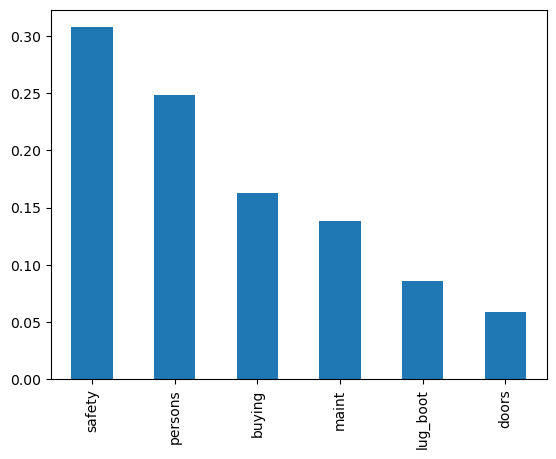

In [12]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind="bar")